##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class**

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [1]:
!pip install -q tensorflow tensorflow_hub opencv-python matplotlib pillow

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
# Load the pre-trained Mask R-CNN model
model_handle = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"
instance_detector = hub.load(model_handle)

print("Mask R-CNN Model loaded.")

Mask R-CNN Model loaded.


In [9]:
# Dictionary mapping for COCO dataset categories
OBJECT_LABELS = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench',
    16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep',
    21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe',
    27: 'backpack', 28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase',
    34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite',
    39: 'baseball bat', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard',
    43: 'tennis racket', 44: 'bottle', 46: 'wine glass', 47: 'cup', 48: 'fork',
    49: 'knife', 50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple',
    54: 'sandwich', 55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog',
    59: 'pizza', 60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch',
    64: 'potted plant', 65: 'bed', 67: 'dining table', 70: 'toilet',
    72: 'tv', 73: 'laptop', 74: 'mouse', 75: 'remote', 76: 'keyboard',
    77: 'cell phone', 78: 'microwave', 79: 'oven', 80: 'toaster', 81: 'sink',
    82: 'refrigerator', 84: 'book', 85: 'clock', 86: 'vase', 87: 'scissors',
    88: 'teddy bear', 89: 'hair drier', 90: 'toothbrush'
}

# The image that i will process
my_image_list = [
    "/content/image1.png",
    "/content/image2.jpg",
    "/content/image3.png",
    "/content/image4.jpeg",
    "/content/image5.avif"
]

def open_and_prepare_image(path):
    """Loads an image from a local path and converts it to a numpy array."""
    img_data = Image.open(path).convert("RGB")
    return np.array(img_data)

print("Configuration complete. Ready to process images.")

Configuration complete. Ready to process images.


In [10]:
def run_model_inference(image_np):
    """Performs object detection and segmentation on the input image."""
    # Convert image to tensor and add batch dimension
    img_input = tf.convert_to_tensor(image_np)
    img_input = img_input[tf.newaxis, ...]

    # Run the model
    output_dict = instance_detector(img_input)

    # Parse the outputs to numpy for visualization
    results = {
        'boxes': output_dict['detection_boxes'][0].numpy(),
        'classes': output_dict['detection_classes'][0].numpy().astype(int),
        'scores': output_dict['detection_scores'][0].numpy(),
        'masks': output_dict['detection_masks'][0].numpy()
    }
    return results

In [11]:
def plot_segmentation_results(img, results, confidence_level=0.5):
    """Draws boxes, labels, and masks using a unique color for each detection."""
    h, w, _ = img.shape
    canvas = img.copy()

    for i in range(len(results['scores'])):
        if results['scores'][i] < confidence_level:
            continue

        # 1. Generate a random color for this specific object (RGB)
        # We use a list to ensure compatibility with OpenCV functions
        target_color = np.random.randint(0, 255, size=3).tolist()

        # Get box coordinates
        ymin, xmin, ymax, xmax = results['boxes'][i]
        left, right, top, bottom = int(xmin * w), int(xmax * w), int(ymin * h), int(ymax * h)

        # Retrieve label name
        class_name = OBJECT_LABELS.get(results['classes'][i], 'Object')
        display_str = f"{class_name}: {int(results['scores'][i] * 100)}%"

        # 2. Draw Bounding Box using the unique color
        cv2.rectangle(canvas, (left, top), (right, bottom), target_color, 3)

        # 3. Add Text Label using the same unique color
        # We use FONT_HERSHEY_DUPLEX for a professional look
        cv2.putText(canvas, display_str, (left, top - 10),
                    cv2.FONT_HERSHEY_DUPLEX, 0.7, target_color, 2)

        # 4. Process and overlay the mask
        mask = results['masks'][i]
        mask_resized = cv2.resize(mask, (right - left, bottom - top))
        mask_binary = (mask_resized > 0.5)

        # Get the Region of Interest (ROI)
        roi = canvas[top:bottom, left:right]

        # Convert color to numpy array for blending math
        color_array = np.array(target_color, dtype=np.uint8)

        # 5. Apply the same color to the mask (Shading)
        # Using 0.5 alpha for a balanced transparency
        if mask_binary.any():
            roi[mask_binary] = (roi[mask_binary] * 0.5 + color_array * 0.5).astype(np.uint8)

    # Display the final results
    plt.figure(figsize=(12, 12))
    plt.imshow(canvas)
    plt.axis('off')
    plt.title(f"Instance Segmentation - Threshold: {confidence_level}")
    plt.show()

Processing: /content/image1.png
Displaying results with 0.5 Confidence Level...


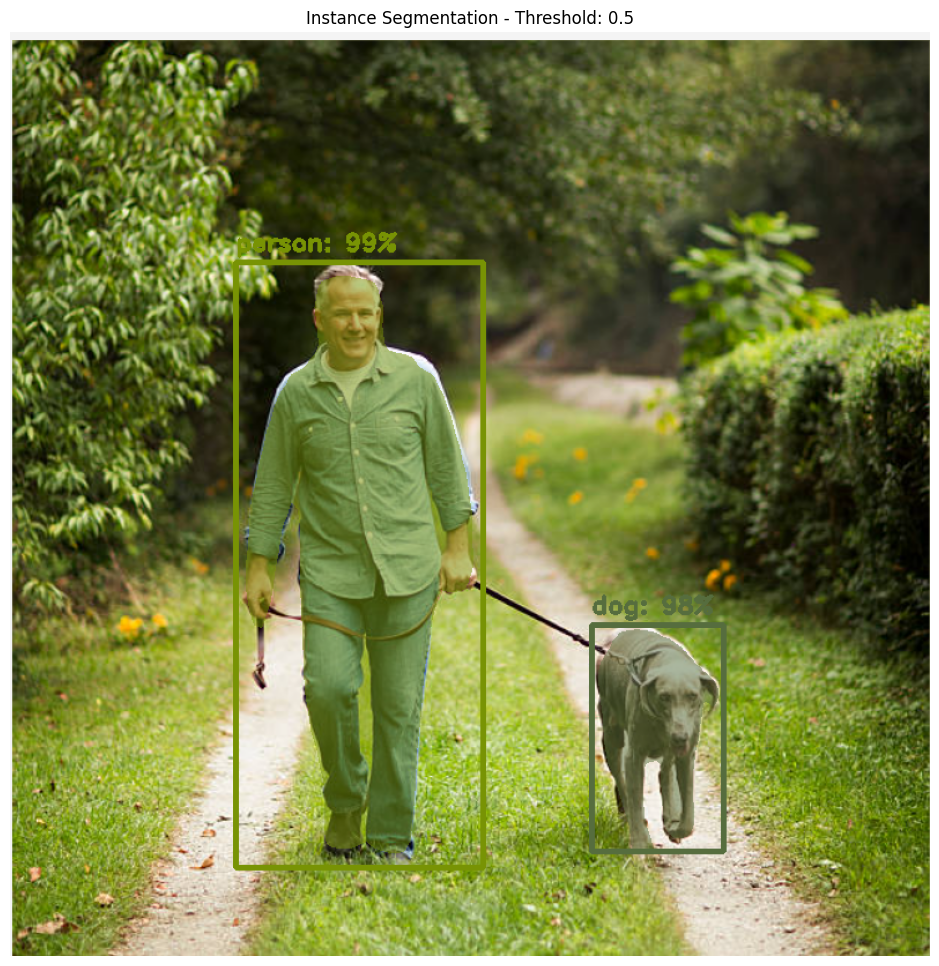

Processing: /content/image2.jpg
Displaying results with 0.5 Confidence Level...


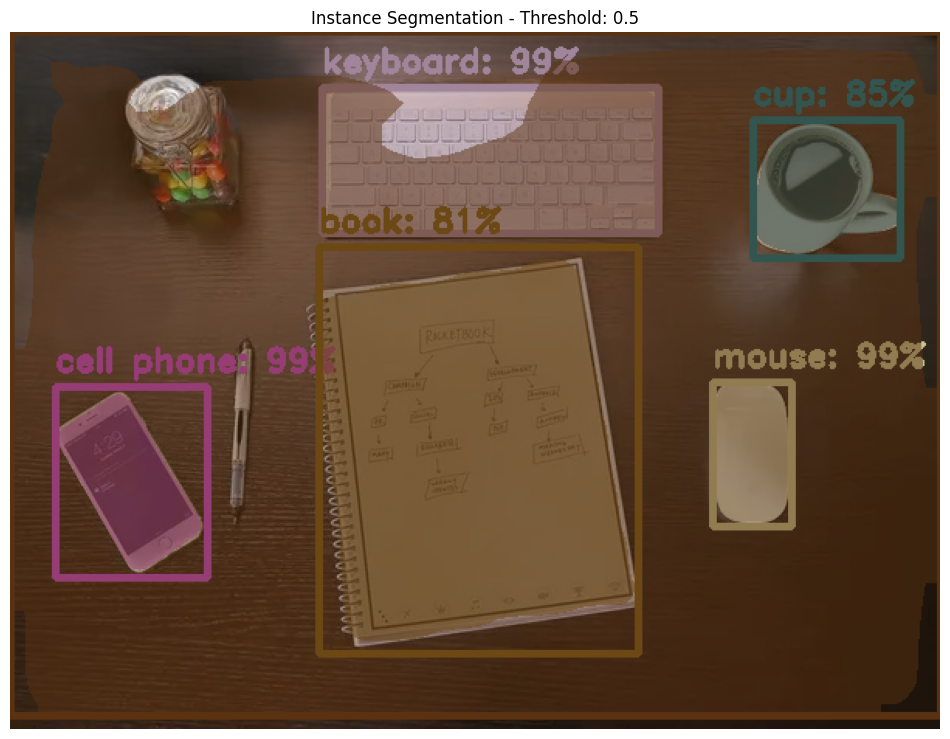

Processing: /content/image3.png
Displaying results with 0.5 Confidence Level...


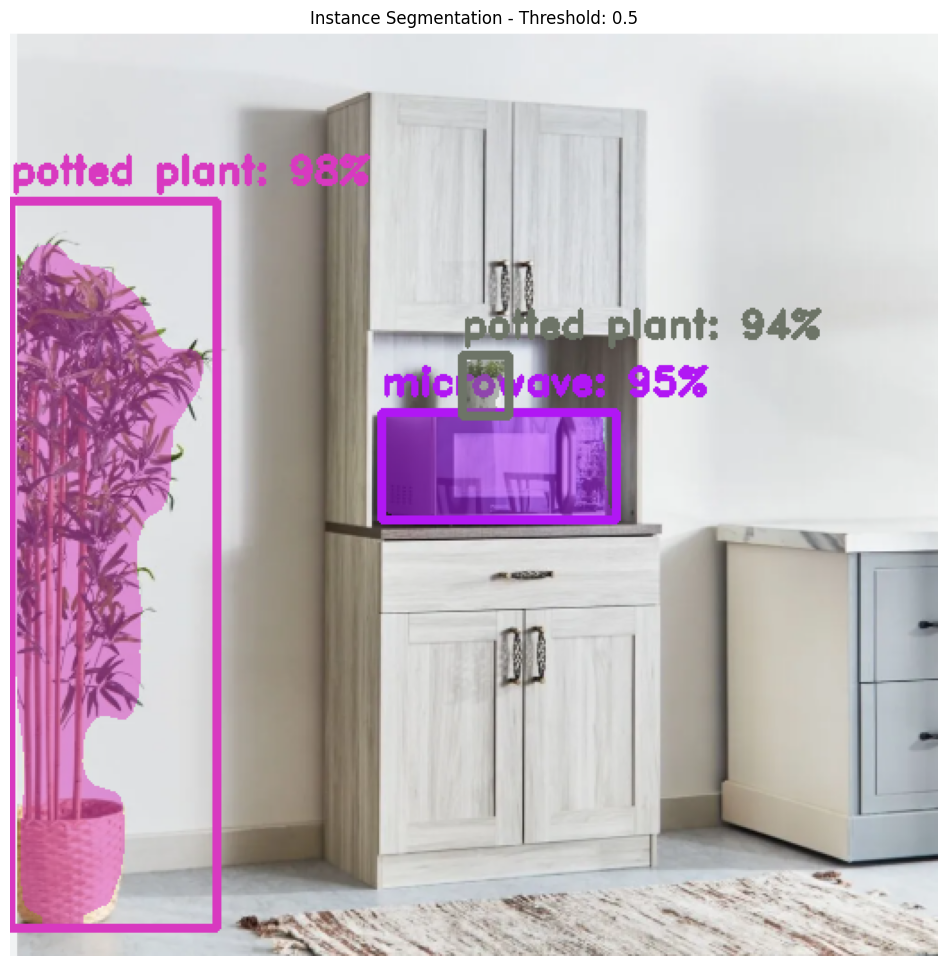

Processing: /content/image4.jpeg
Displaying results with 0.5 Confidence Level...


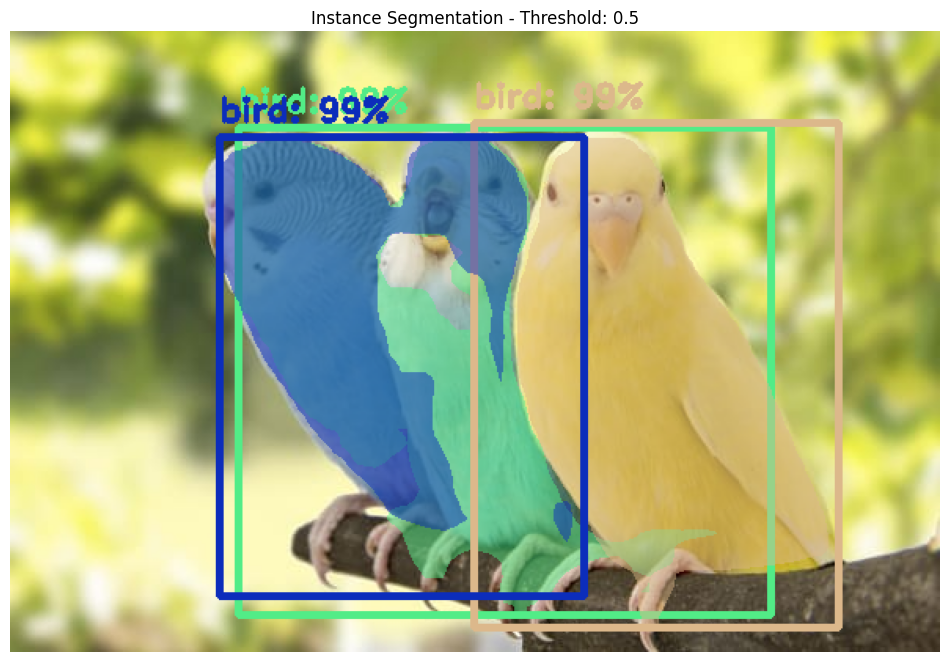

Processing: /content/image5.avif
Displaying results with 0.5 Confidence Level...


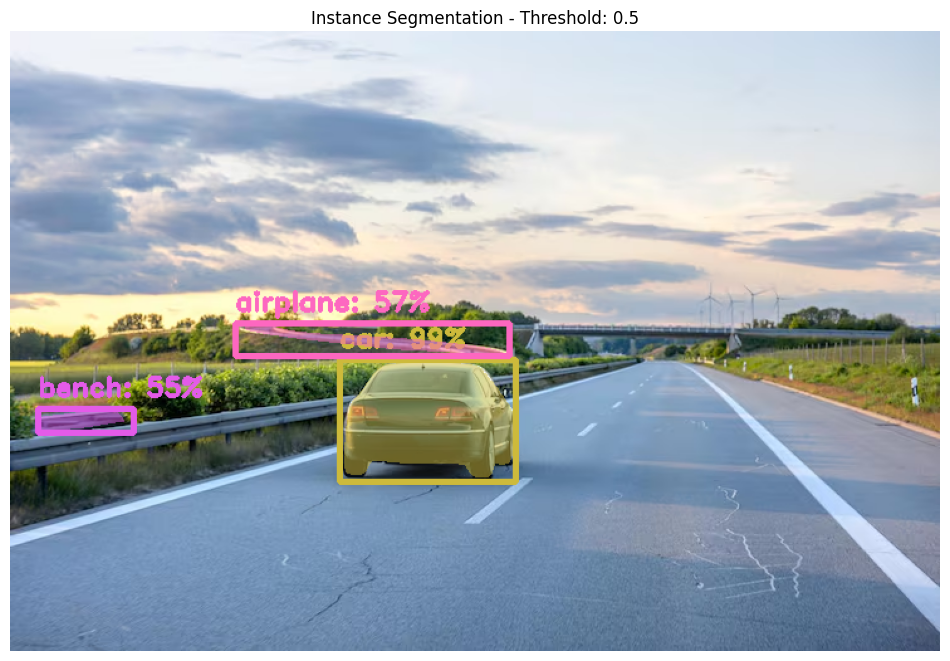

In [12]:
# Process all images with 0.5 confidence threshold
for path in my_image_list:
    print(f"Processing: {path}")

    # Load and prepare image
    image_array = open_and_prepare_image(path)

    # Generate model predictions
    data = run_model_inference(image_array)

    # Display results for 0.5 threshold
    print("Displaying results with 0.5 Confidence Level...")
    plot_segmentation_results(image_array, data, confidence_level=0.5)

Processing: /content/image1.png
Displaying results with 0.3 Confidence Level...


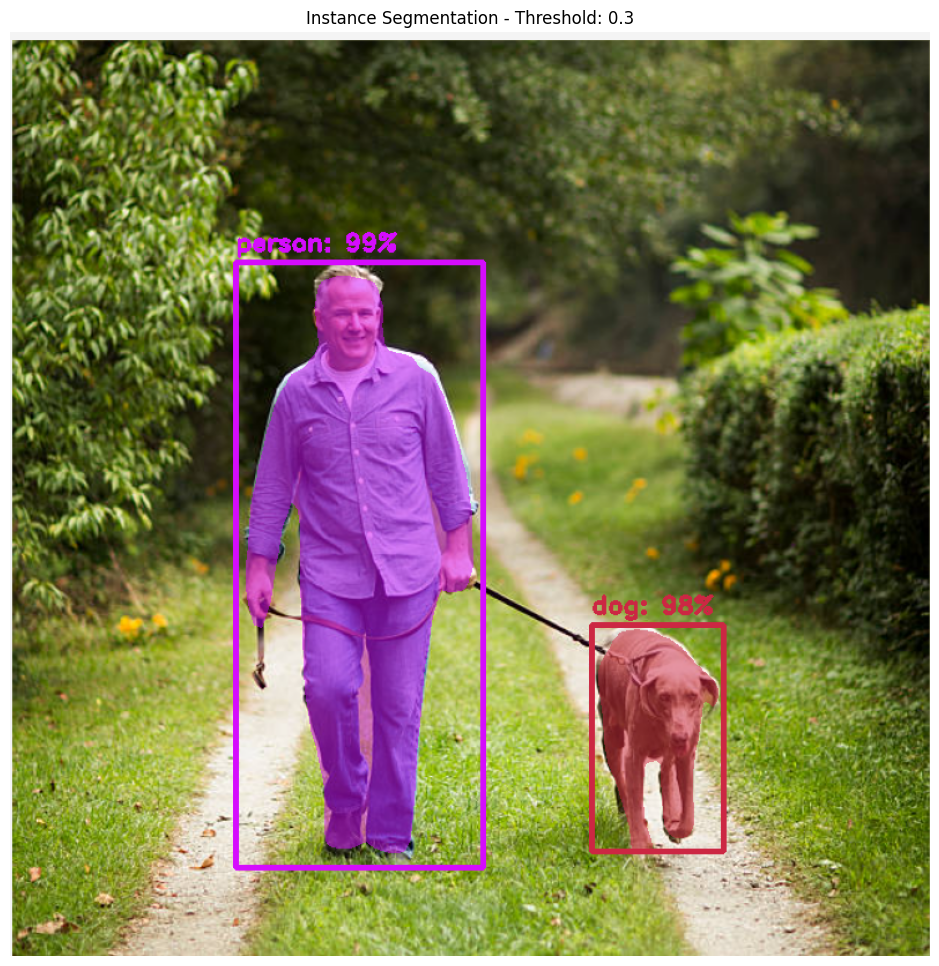

Processing: /content/image2.jpg
Displaying results with 0.3 Confidence Level...


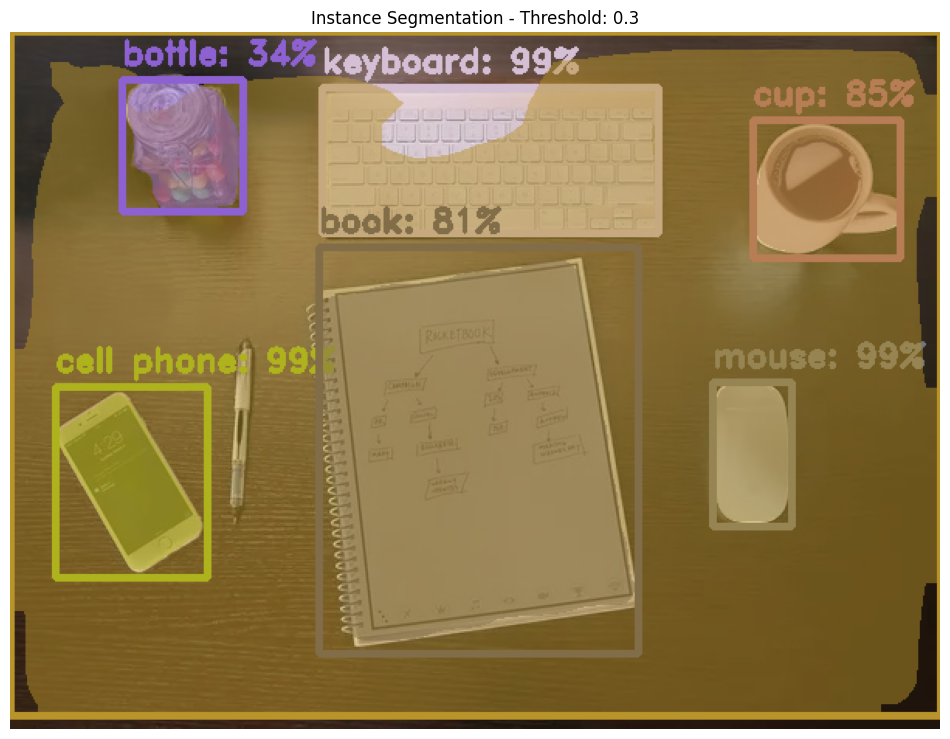

Processing: /content/image3.png
Displaying results with 0.3 Confidence Level...


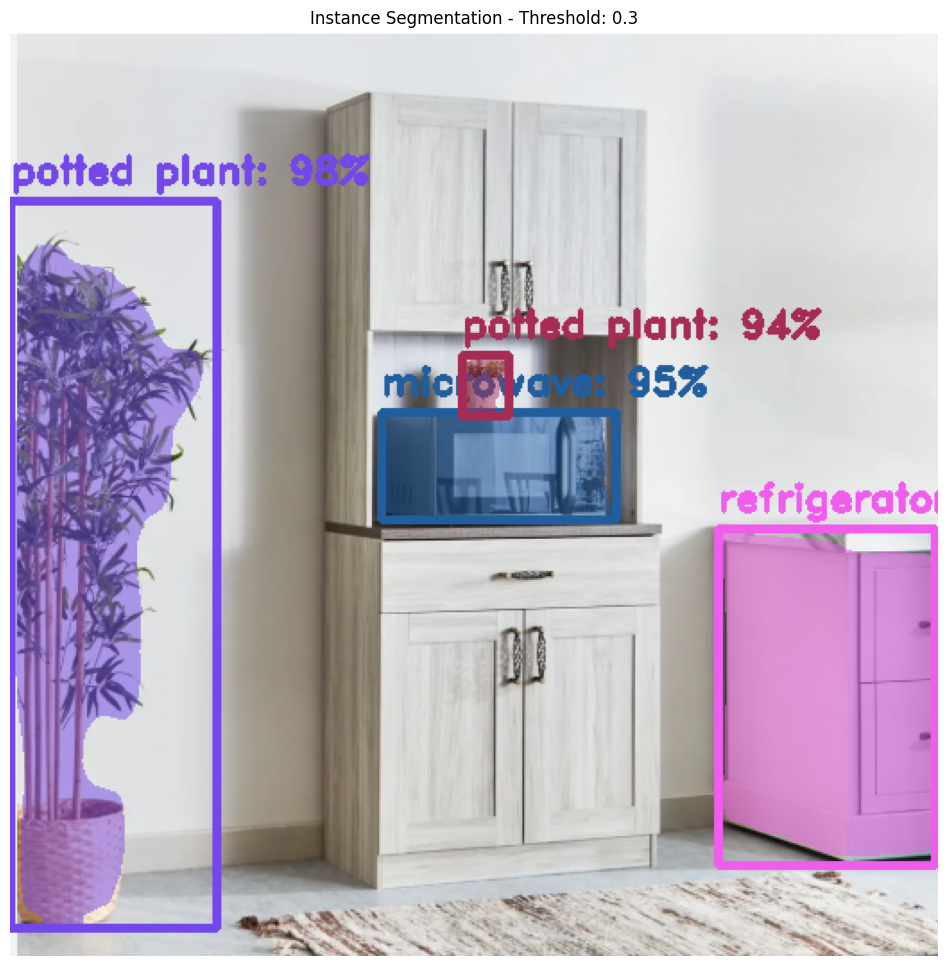

Processing: /content/image4.jpeg
Displaying results with 0.3 Confidence Level...


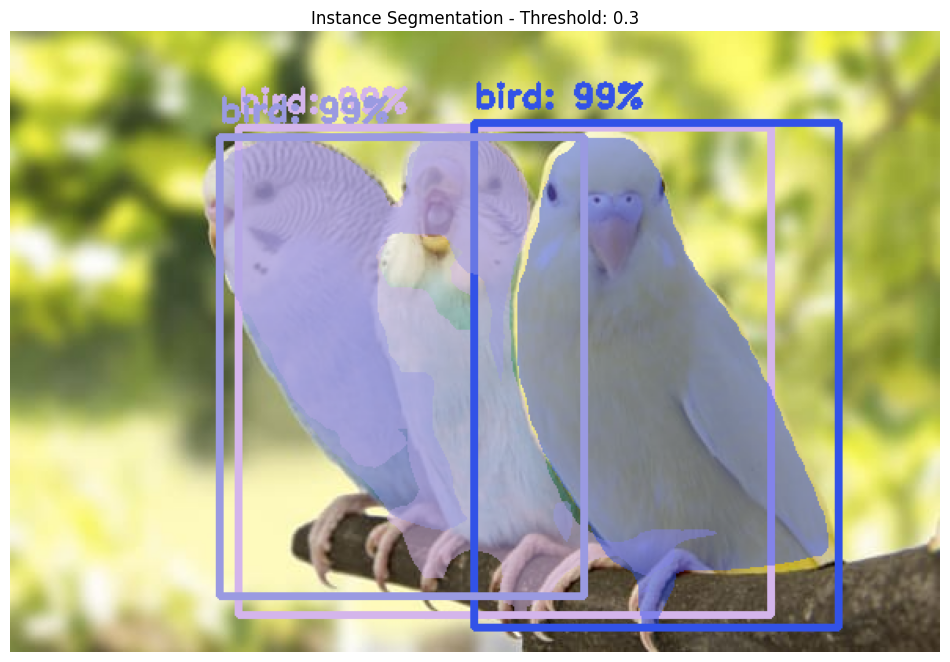

Processing: /content/image5.avif
Displaying results with 0.3 Confidence Level...


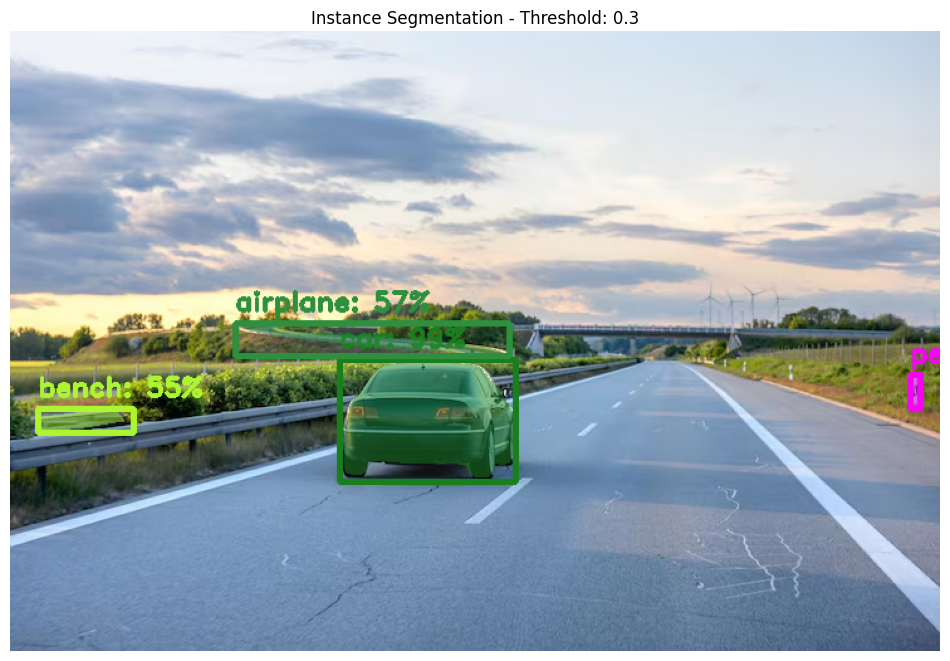

In [13]:
# Process all images with 0.3 confidence threshold
for path in my_image_list:
    print(f"Processing: {path}")

    # Load and prepare image
    image_array = open_and_prepare_image(path)

    # Generate model predictions
    data = run_model_inference(image_array)

    # Display results for 0.3 threshold
    print("Displaying results with 0.3 Confidence Level...")
    plot_segmentation_results(image_array, data, confidence_level=0.3)